# ARMA

## Import libraries

In [15]:
import warnings
import ccxt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [16]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

In [17]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
TEST_SPLIT_RATIO = 0.15
WINDOW_SIZE = 240
AR_ORDER_CANDIDATES = range(0, 3)
MA_ORDER_CANDIDATES = range(0, 3)
FORECAST_STEPS = 24
OUTPUT_VALUE = "log_return_close"

## Fetching data

In [18]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=1000,
        )
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [19]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [20]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [21]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [22]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Splitting data

In [23]:
series = data[OUTPUT_VALUE].copy()

test_start = int(len(series) * (1 - TEST_SPLIT_RATIO))
history_seed = series.iloc[:test_start]
test_series = series.iloc[test_start:]
test_returns = data.loc[test_series.index, "return_close"].copy()

if WINDOW_SIZE >= len(history_seed):
    raise ValueError("WINDOW_SIZE must be smaller than the number of observations available before the test split.")

In [24]:
split_summary = pd.DataFrame(
    {"samples": [len(history_seed), len(test_series)]},
    index=["history_before_test", "test"],
)
split_summary

,samples
history_before_test,18151
test,3204


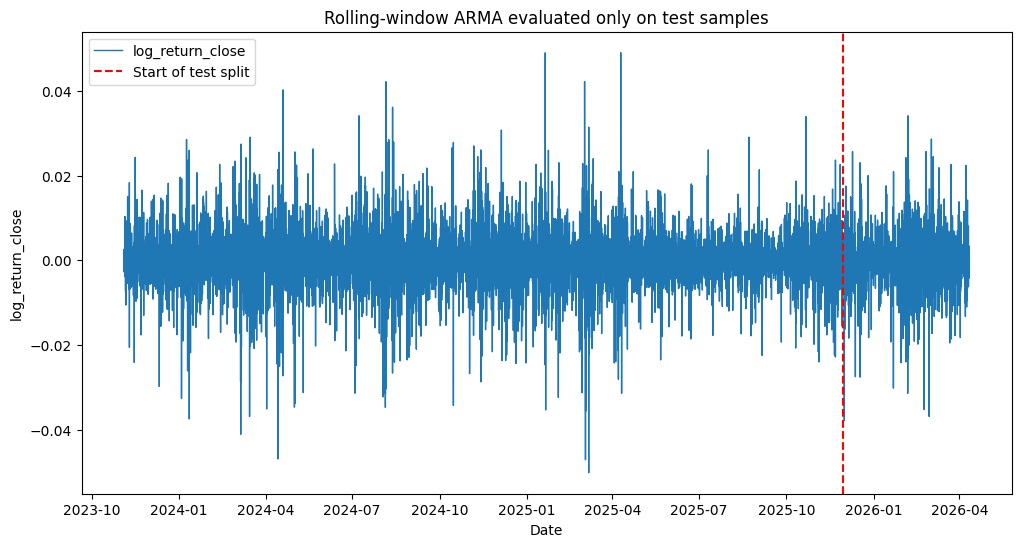

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(series.index, series, label=OUTPUT_VALUE, linewidth=1)
plt.axvline(test_series.index[0], color="red", linestyle="--", label="Start of test split")
plt.title("Rolling-window ARMA evaluated only on test samples")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

In [26]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)


def fit_arma(series, ar_order, ma_order):
    return ARIMA(
        series,
        order=(ar_order, 0, ma_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()


def select_best_arma_model(window_series, ar_candidates, ma_candidates):
    best_result = None
    for ar_order in ar_candidates:
        for ma_order in ma_candidates:
            if ar_order == 0 and ma_order == 0:
                continue
            try:
                candidate_result = fit_arma(window_series, ar_order, ma_order)
                if best_result is None or candidate_result.aic < best_result["AIC"]:
                    best_result = {
                        "model": candidate_result,
                        "p": ar_order,
                        "q": ma_order,
                        "AIC": candidate_result.aic,
                    }
            except Exception:
                continue

    if best_result is None:
        raise ValueError("No ARMA configuration could be fitted for the current window.")

    return best_result


def forecast_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    directional_accuracy = ((y_true > 0) == (y_pred > 0)).mean()
    return pd.Series(
        {
            "MAE": mae,
            "RMSE": rmse,
            "Directional accuracy": directional_accuracy,
        }
    )


def rolling_window_forecast(history_series, forecast_index, window_size, ar_candidates, ma_candidates, actual_values=None, label="forecast"):
    history = history_series.copy()
    predictions = []
    selected_orders = []
    total_steps = len(forecast_index)

    for step, timestamp in enumerate(forecast_index, start=1):
        window_series = history.iloc[-window_size:]
        best_result = select_best_arma_model(window_series, ar_candidates, ma_candidates)
        prediction = best_result["model"].forecast(steps=1).iloc[0]

        predictions.append(prediction)
        selected_orders.append(
            {
                "Date": timestamp,
                "p": best_result["p"],
                "q": best_result["q"],
                "AIC": best_result["AIC"],
            }
        )

        next_value = actual_values.loc[timestamp] if actual_values is not None else prediction
        history = pd.concat([history, pd.Series([next_value], index=[timestamp])])

        if step % 100 == 0 or step == total_steps:
            print(f"{label}: processed {step}/{total_steps} steps")

    selected_orders_df = pd.DataFrame(selected_orders).set_index("Date")
    forecast_series = pd.Series(predictions, index=forecast_index)
    return forecast_series, selected_orders_df

In [27]:
print(f"Rolling window size: {WINDOW_SIZE}")
print(f"AR candidates: {list(AR_ORDER_CANDIDATES)}")
print(f"MA candidates: {list(MA_ORDER_CANDIDATES)}")
print("ARMA models are fitted only for timestamps that belong to the test split.")

Rolling window size: 240
AR candidates: [0, 1, 2]
MA candidates: [0, 1, 2]
ARMA models are fitted only for timestamps that belong to the test split.


## Rolling ARMA fitting

In [28]:
test_forecast, selected_orders_df = rolling_window_forecast(
    history_series=history_seed,
    forecast_index=test_series.index,
    window_size=WINDOW_SIZE,
    ar_candidates=AR_ORDER_CANDIDATES,
    ma_candidates=MA_ORDER_CANDIDATES,
    actual_values=series,
    label="test",
)

test: processed 100/3204 steps
test: processed 200/3204 steps
test: processed 300/3204 steps
test: processed 400/3204 steps
test: processed 500/3204 steps
test: processed 600/3204 steps
test: processed 700/3204 steps
test: processed 800/3204 steps
test: processed 900/3204 steps
test: processed 1000/3204 steps
test: processed 1100/3204 steps
test: processed 1200/3204 steps
test: processed 1300/3204 steps
test: processed 1400/3204 steps
test: processed 1500/3204 steps
test: processed 1600/3204 steps
test: processed 1700/3204 steps
test: processed 1800/3204 steps
test: processed 1900/3204 steps
test: processed 2000/3204 steps
test: processed 2100/3204 steps
test: processed 2200/3204 steps
test: processed 2300/3204 steps
test: processed 2400/3204 steps
test: processed 2500/3204 steps
test: processed 2600/3204 steps
test: processed 2700/3204 steps
test: processed 2800/3204 steps
test: processed 2900/3204 steps
test: processed 3000/3204 steps
test: processed 3100/3204 steps
test: processed 3

In [29]:
selected_orders_df.head(10)

,p,q,AIC
Date,,,
2025-11-29 04:00:00,1,0,-1745.566512
2025-11-29 05:00:00,1,0,-1747.088511
2025-11-29 06:00:00,1,0,-1747.834984
2025-11-29 07:00:00,1,0,-1750.256977
2025-11-29 08:00:00,1,0,-1750.658050
2025-11-29 09:00:00,1,0,-1750.648013
2025-11-29 10:00:00,1,0,-1750.753971
2025-11-29 11:00:00,1,0,-1750.781282
2025-11-29 12:00:00,1,0,-1751.182215


## Verifying model

In [30]:
comparison_df = pd.DataFrame(
    {
        "y_true": test_series,
        "y_pred": test_forecast,
    }
)
comparison_df.head(10)

,y_true,y_pred
Date,,
2025-11-29 04:00:00,0.002437,0.000012
2025-11-29 05:00:00,-0.001700,-0.000075
2025-11-29 06:00:00,-0.002006,0.000039
2025-11-29 07:00:00,0.000026,0.000012
2025-11-29 08:00:00,0.000684,-0.000050
2025-11-29 09:00:00,-0.000768,-0.000064
2025-11-29 10:00:00,-0.000084,-0.000016
2025-11-29 11:00:00,0.001332,-0.000036
2025-11-29 12:00:00,-0.000631,-0.000104


In [31]:
test_metrics = forecast_metrics(comparison_df["y_true"], comparison_df["y_pred"])
print("Test metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.6f}")

Test metrics:
MAE: 0.003452
RMSE: 0.005257
Directional accuracy: 0.482834


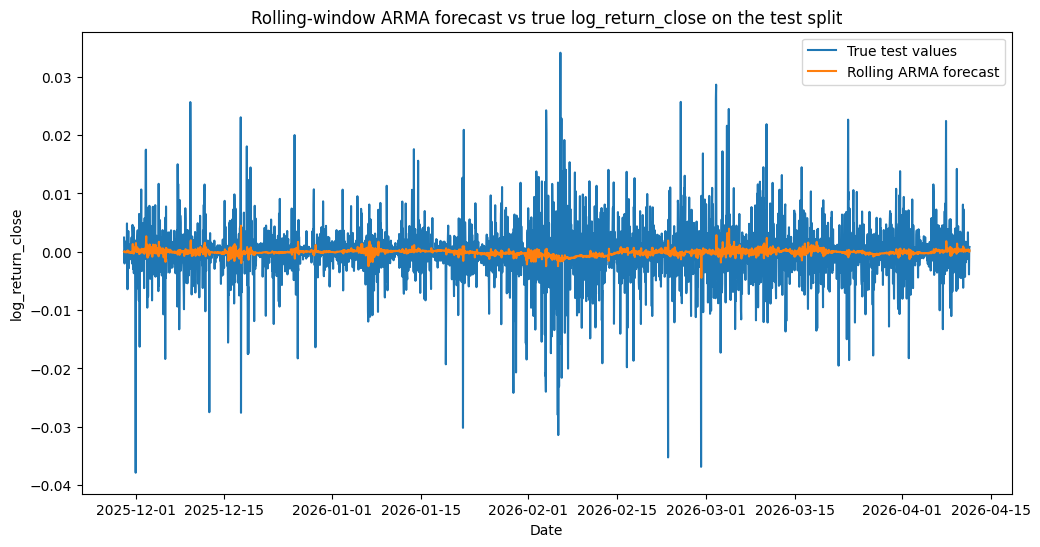

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df["y_true"], label="True test values")
plt.plot(comparison_df.index, comparison_df["y_pred"], label="Rolling ARMA forecast")
plt.title("Rolling-window ARMA forecast vs true log_return_close on the test split")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

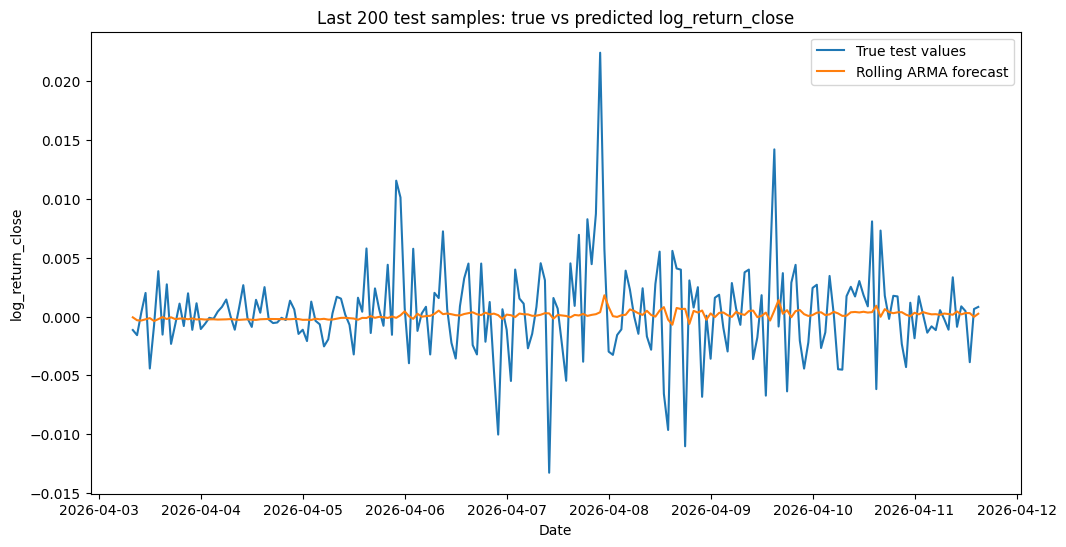

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.tail(200).index, comparison_df.tail(200)["y_true"], label="True test values")
plt.plot(comparison_df.tail(200).index, comparison_df.tail(200)["y_pred"], label="Rolling ARMA forecast")
plt.title("Last 200 test samples: true vs predicted log_return_close")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

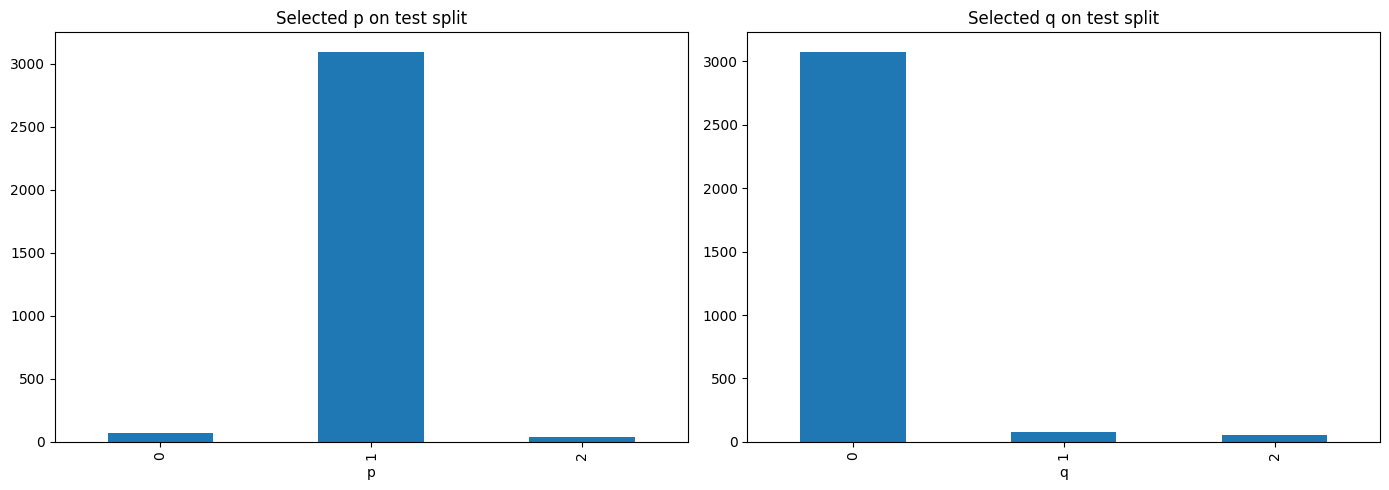

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
selected_orders_df["p"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Selected p on test split")
selected_orders_df["q"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Selected q on test split")
axes[0].set_xlabel("p")
axes[1].set_xlabel("q")
plt.tight_layout()
plt.show()

## Backtesting model

Final cash: 544.32
Strategy return: -45.57%
Buy and hold return: -19.76%


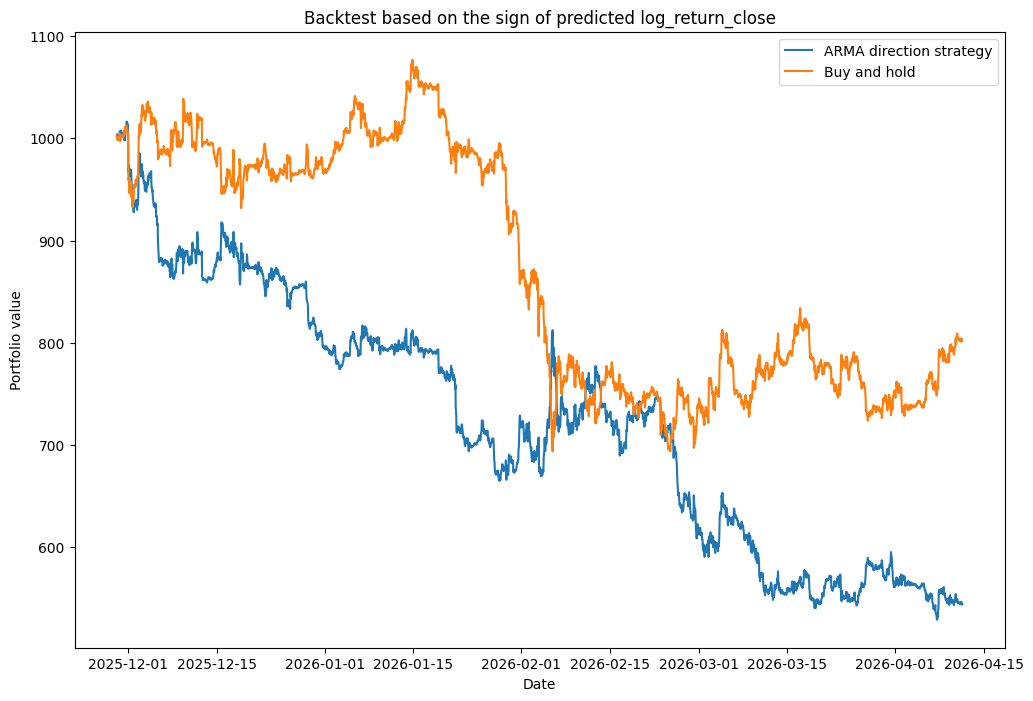

In [35]:
strategy_returns = pd.Series(
    np.where(test_forecast > 0, test_returns, -test_returns),
    index=test_returns.index,
)

start_cash = 1000.0
strategy_curve = start_cash * (1 + strategy_returns).cumprod()
buy_and_hold_curve = start_cash * (1 + test_returns).cumprod()

print(f"Final cash: {strategy_curve.iloc[-1]:.2f}")
print(f"Strategy return: {(strategy_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")

plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="ARMA direction strategy")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Buy and hold")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.title("Backtest based on the sign of predicted log_return_close")
plt.legend()
plt.show()